# Grains segmentation of an orientation map (3/3)

The segmentation code is in the module `LaueTools/orientationclustering.py` (`OC` below).

- two UB matrices are linked if they belong to the **same or neighbouring map points** and their **misorientation < threshold**; clusters (grains) are the connected components
- all grains of the `.fit` files are used (`_g0`, `_g1`, ... several grains per map point)
- UB matrices are orthonormalised (polar decomposition) and misorientations take into account the **crystal symmetry** (24 equivalent orientations for cubic)
- map convention: `mapdimension = invmapdims = (nb rows = slow axis, nb cols = fast axis)`, image index = row * nb cols + col
- cluster ids are sorted by decreasing size (cluster 0 is the largest)

**This notebook is part of the LaueTools package** (https://github.com/BM32ESRF/lauetools)

Author: J.-S. Micha, Last revision: Sept 2026. Tested with python 3.12 (jupyterlab, jupyterhub, VS Code)

| notebook | input | output |
|---|---|---|
| `1_index_refine.ipynb` | `.cor` files (peak search results) | `.fit` files (indexed spots, UB matrix, strain per grain) |
| `2_postprocess_maps.ipynb` | `.fit` files | maps & statistics: nb of spots, pixel deviation, strain, lattice parameters, orientation |
| `3_segmentation_grains.ipynb` | `.fit` files | grains (clusters of orientation), KAM, GROD, boundaries |

**All settings of an experiment are in a YAML configuration file**: copy `config_template.yaml` to `configs/my_experiment.yaml`, edit it and set `CONFIG` in the first code cell. The same file is used by the 3 notebooks. `configs/` contains examples of BM32 datasets (access to ESRF `/data` needed).

# SETTINGS

In [1]:
CONFIG = 'configs/a321220_MgO.yaml'   # configuration file of your experiment

FIT_FOLDER = None       # None: output fit_folder of the configuration file
THRESHOLD = .8          # deg, max misorientation between neighbouring points of a grain
MIN_CLUSTER_SIZE = 15    # min nb of points of a grain

# IMPORTS

In [2]:
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    import ipympl  # interactive plots (zoom, hover) in JupyterLab / VS Code
    %matplotlib widget
except ImportError:
    %matplotlib inline

import LaueTools.indexing_batch as IB
import LaueTools.orientationclustering as OC

loading lauetools_config.json in  /mnt/multipath-shares/data/bm32/inhouse/SOFT/lauetoolsDEV/lauetools/LaueTools
No user materials.yaml found. Using default materials.yaml
-- warning: sklearn.metrics is not installed. For matchingrate.py module, it could be useful... but not necessary
-- WARNING: module Image or PIL is not installed, but only used for templateimagematching
loading readmccd.py
-- WARNING: Missing library libtiff, Please install: pylibtiff if you need open some tiff images. However, Fabio or PIL can do the job!
hostname = hpc6-03


# LOAD CONFIGURATION

In [3]:
cfg = IB.load_config(CONFIG)
IB.print_config(cfg)
scan, post = cfg['scan'], cfg['postprocess']
mapdims, invmapdims = scan['mapdims'], scan['invmapdims']   # (fast, slow), (slow, fast)
fit_folder = Path(FIT_FOLDER) if FIT_FOLDER else cfg['output']['fit_folder']

fit_folder = '/data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/fitfiles_MgO_6grains'
print('.fit files in', fit_folder)

---- a321220 MgO ----  (/gpfs/jazzy/data/bm32/inhouse/SOFT/lauetoolsDEV/lauetools/LaueTools/notebooks/indexation/configs/a321220_MgO.yaml)
.cor files:  /data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/corfiles/eiger4m_####.cor
.fit files:  /data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/fitfiles_MgO
map:         mapdims (fast, slow) = (51, 51), motors (yech, xech)
detector:    EIGER_4MCdTe, calibration /data/visitor/a321220/bm32/20260915/RAW_DATA/MH73/MH73_Ge/scan0001/calibGe001_MH73_RT_mardi.det
material:    MgO, energy 5-22 keV (indexing up to 19 keV), nbGrainstoFind = 3
.fit files in /data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/fitfiles_MgO_6grains


# RUN segmentation

In [4]:
t0 = time.time()
result, analyzer = OC.analyze_ub_matrices(input_dir=fit_folder,
                                          threshold=THRESHOLD,          # max misorientation (deg) between neighbouring points
                                          mapdimension=invmapdims,      # (nb rows = slow axis, nb cols = fast axis)
                                          prefix=scan['prefix'],        # e.g. eiger4m_0123_g0.fit
                                          symmetry=post['symmetry'],    # 'auto': cubic if all materials are cubic, None: raw angles
                                          spatial_connectivity=True,
                                          connectivity_type='8',        # '4': edges only, '8': edges + corners
                                          min_cluster_size=MIN_CLUSTER_SIZE,
                                          check_symmetry=True)          # ALARM if matrices are equivalent by symmetry but not reduced
print(f'elapsed time {time.time() - t0:.2f} s')
print(f"Grain indices: {analyzer.get_all_grain_indices()}")
OC.print_cluster_summary(result, analyzer, nb_max=20)

    img 1621 g4 <-> img 1672 g4: raw 89.27°, reduced 1.055°
    img 1621 g4 <-> img 1673 g4: raw 89.37°, reduced 0.948°
    img 1622 g3 <-> img 1672 g4: raw 89.15°, reduced 1.505°
    img 1622 g3 <-> img 1673 g4: raw 89.26°, reduced 1.402°
    img 1623 g3 <-> img 1673 g4: raw 89.28°, reduced 1.398°
NOTE: 5 UB matrices far from a rotation (singular values off by > 5%): poor refinement?
    img 169 g4: singular values [1.003, 0.979, 0.947]
    img 203 g3: singular values [1.043, 0.99, 0.947]
    img 300 g3: singular values [1.051, 1.007, 0.923]
    img 347 g3: singular values [1.007, 0.978, 0.944]
    img 2490 g5: singular values [1.052, 1.023, 0.981]
elapsed time 43.97 s
Grain indices: [0, 1, 2, 3, 4, 5]
ClusterResult(81 clusters, threshold=0.8°, symmetry=cubic, mode=all_connected_8): 13709/15016 matrices assigned
  Cluster   0:  4574 matrices,  2243 pixels, mean (row, col)=( 18.6,  25.0), ref img   994, std=0.87°, max dev=3.53°, grains [0, 1, 2, 3, 4, 5]
  Cluster   1:   784 matrices, 

## symmetry check

`check_symmetry_equivalents()` compares matrices of the same and neighbouring map points. It warns when two matrices look very different (raw angle > `angle_tol`) but are equivalent by crystal symmetry, i.e. when the matrices of the .fit files have **not** been reduced to a common representative. The clustering above is symmetry-aware, so it is not affected, but any raw element-wise comparison (e.g. `GT.getRotationAngleFrom2Matrices`, maps of UB elements or Euler angles) is.

`align_to_cluster_reference()` returns the UB matrices transformed (UB.S) to the symmetry variant closest to the reference matrix of their cluster.

In [8]:
report = OC.check_symmetry_equivalents(analyzer, symmetry=result.symmetry, angle_tol=2.0, verbose=False)
print(f"{len(report['sym_equivalent_pairs'])} neighbouring pairs equivalent by symmetry only")
for i, j, raw_angle, reduced_angle in report['sym_equivalent_pairs'][:10]:
    print(f"  {analyzer.matrices[i]} <-> {analyzer.matrices[j]}: raw {raw_angle:.1f}°, reduced {reduced_angle:.2f}°")

# UB matrices brought to a common symmetry representative within each cluster, shape (nb matrices, 3, 3)
UB_aligned = OC.align_to_cluster_reference(result, analyzer)

16 neighbouring pairs equivalent by symmetry only
  UBMatrix(image=1621, grain=4, material=MgO, nb_indexed=19, file=eiger4m_1621_g4.fit) <-> UBMatrix(image=1672, grain=4, material=MgO, nb_indexed=22, file=eiger4m_1672_g4.fit): raw 89.3°, reduced 1.05°
  UBMatrix(image=1621, grain=4, material=MgO, nb_indexed=19, file=eiger4m_1621_g4.fit) <-> UBMatrix(image=1673, grain=4, material=MgO, nb_indexed=25, file=eiger4m_1673_g4.fit): raw 89.4°, reduced 0.95°
  UBMatrix(image=1622, grain=3, material=MgO, nb_indexed=25, file=eiger4m_1622_g3.fit) <-> UBMatrix(image=1672, grain=4, material=MgO, nb_indexed=22, file=eiger4m_1672_g4.fit): raw 89.2°, reduced 1.50°
  UBMatrix(image=1622, grain=3, material=MgO, nb_indexed=25, file=eiger4m_1622_g3.fit) <-> UBMatrix(image=1673, grain=4, material=MgO, nb_indexed=25, file=eiger4m_1673_g4.fit): raw 89.3°, reduced 1.40°
  UBMatrix(image=1623, grain=3, material=MgO, nb_indexed=22, file=eiger4m_1623_g3.fit) <-> UBMatrix(image=1673, grain=4, material=MgO, nb_inde

# CLUSTERS statistics

In [15]:
# find cluster seen in a given sample pt (or image index)

# ClusterStats by cluster id (do not index the list returned by get_cluster_stats() with a cluster id)
stats_by_id = result.get_cluster_stats_dict(analyzer)

testimageindex = post['reference_image_index'] or cfg['run']['test_image_index']
for stats in result.get_cluster_stats_by_image(analyzer, image_index=testimageindex):
    print(f"Cluster {stats.cluster_id} contains image {testimageindex}")
    print(f"  {stats}")
    print(f"  reference UB matrix (image {stats.reference_image_index}): {stats.reference_matrix.tolist()}")
    print(f"  distribution of misorientations to reference: {OC.get_angular_deviation_distribution(stats)}")

Cluster 0 contains image 1300
  ClusterStats(id=0, size=4574, pixels=2243, ref_img=994, mean (row, col)=(18.6, 25.0), std_orient=0.87°, max_dev=3.53°)
  reference UB matrix (image 994): [[0.882764269, 0.401209427, 0.242725272], [-0.416111538, 0.907261973, 0.011538744], [-0.21545568, -0.11151946, 0.970026167]]
  distribution of misorientations to reference: {'mean': 1.7211157745051768, 'std': 0.865905959550522, 'min': 0.0, 'max': 3.5279859097369877, 'median': 1.821988039099637, 'q25': 0.8929974660033684, 'q75': 2.33380360521972}
Cluster 1 contains image 1300
  ClusterStats(id=1, size=784, pixels=758, ref_img=1548, mean (row, col)=(29.5, 18.1), std_orient=0.12°, max_dev=0.94°)
  reference UB matrix (image 1548): [[0.75014231, -0.618853808, 0.241006981], [0.630077199, 0.548838357, -0.549096339], [0.206663052, 0.562563881, 0.800506958]]
  distribution of misorientations to reference: {'mean': 0.11502495519931924, 'std': 0.11934967778605031, 'min': 0.0, 'max': 0.9367700693252031, 'median': 

In [10]:
# reference UB matrix of each cluster (as written in the .fit file of the point closest to the cluster barycenter)
# printed as copy-paste ready lists (e.g. ub_matrices of the configuration file); which='mean': mean orientation
refs = OC.get_reference_matrices(result, analyzer, min_size=30, which='reference')
UBlist = [np.array(m) for m in refs.values()]

# cluster 0 (2243 pts, ref image 994)
[[0.882764269, 0.401209427, 0.242725272], [-0.416111538, 0.907261973, 0.011538744], [-0.215455680, -0.111519460, 0.970026167]]
# cluster 1 (758 pts, ref image 1548)
[[0.750142310, -0.618853808, 0.241006981], [0.630077199, 0.548838357, -0.549096339], [0.206663052, 0.562563881, 0.800506958]]
# cluster 2 (764 pts, ref image 1923)
[[0.717568127, 0.697547996, -0.019076902], [-0.445070297, 0.479193742, 0.755052809], [0.535308650, -0.532885657, 0.653463382]]
# cluster 3 (550 pts, ref image 1292)
[[0.871366775, -0.429199341, -0.239889374], [0.486343415, 0.685621889, 0.539354927], [-0.066644162, -0.585565759, 0.805993549]]
# cluster 4 (407 pts, ref image 649)
[[0.859177441, 0.417459475, 0.262274242], [-0.426609616, 0.898522026, -0.033853000], [-0.252510846, -0.084801770, 0.964371436]]
# cluster 5 (433 pts, ref image 776)
[[0.663612146, -0.423231371, -0.618504688], [0.475968340, 0.874246637, -0.088208160], [0.577286492, -0.235815535, 0.781165237]]
# cluster 

In [11]:
# clusters sorted by orientation spread
for stats in result.get_cluster_stats_sorted(analyzer, sort_by='max_angular_deviation')[:15]:
    row, col = stats.mean_position
    print(f"Cluster {stats.cluster_id:3d}: {stats.nb_pixels:4d} pts, mean (col, row)=({col:.1f}, {row:.1f}), "
          f"std={stats.std_orientation:.2f}°, max misorientation={stats.max_angular_deviation:.2f}°")

Cluster   0: 2243 pts, mean (col, row)=(25.0, 18.6), std=0.87°, max misorientation=3.53°
Cluster  43:   42 pts, mean (col, row)=(22.3, 38.5), std=0.33°, max misorientation=1.51°
Cluster  18:  118 pts, mean (col, row)=(39.0, 36.5), std=0.22°, max misorientation=1.33°
Cluster  42:   47 pts, mean (col, row)=(42.2, 1.0), std=0.18°, max misorientation=1.08°
Cluster  11:  302 pts, mean (col, row)=(26.5, 43.1), std=0.16°, max misorientation=1.07°
Cluster  10:  285 pts, mean (col, row)=(38.4, 19.7), std=0.23°, max misorientation=1.04°
Cluster  49:   38 pts, mean (col, row)=(19.3, 33.0), std=0.22°, max misorientation=1.03°
Cluster  50:   32 pts, mean (col, row)=(12.1, 47.1), std=0.36°, max misorientation=1.03°
Cluster  22:   87 pts, mean (col, row)=(3.3, 12.3), std=0.27°, max misorientation=1.03°
Cluster  21:  107 pts, mean (col, row)=(38.5, 48.4), std=0.17°, max misorientation=1.00°
Cluster   4:  407 pts, mean (col, row)=(37.3, 11.8), std=0.18°, max misorientation=0.99°
Cluster  61:   25 pts, 

In [16]:
# clusters built with spatial connectivity are connected by construction.
# split_non_compact_clusters() is useful after clustering without spatial connectivity
# (max_gap=1: points touching by edge or corner are connected, max_gap=2 bridges 1-point gaps)
split_result = OC.split_non_compact_clusters(result, analyzer, max_gap=1, min_cluster_size=MIN_CLUSTER_SIZE)
print(split_result)
print('cluster 0 compact:', OC.is_cluster_compact(result.get_cluster(0), analyzer))

ClusterResult(81 clusters, threshold=0.8°, symmetry=cubic, mode=all_connected_8_split)
cluster 0 compact: True


# MAPS of clusters

## all clusters

At map points where several grains are indexed (g0, g1, g2 ...), the grain with the largest number of indexed spots is shown. Black lines: boundaries between clusters. Hover the map to read image index and cluster id.

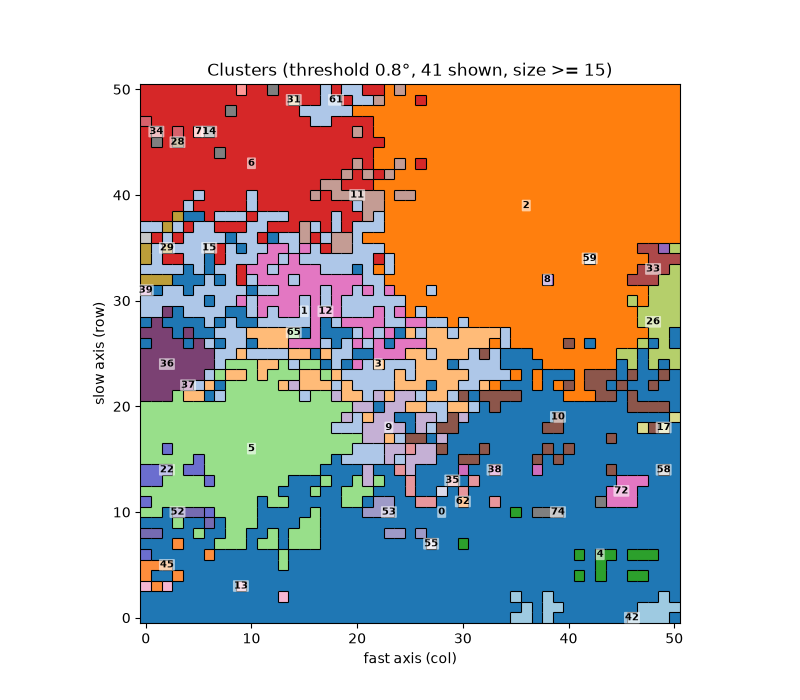

In [13]:
fig, ax = OC.plot_cluster_map(result, analyzer, min_size=MIN_CLUSTER_SIZE, show_ids=True, show_boundaries=True)

## each individual cluster

Each cluster is colored by the misorientation (deg) of its points to the cluster reference matrix (red star: point closest to the cluster barycenter). Gray: other measured points.

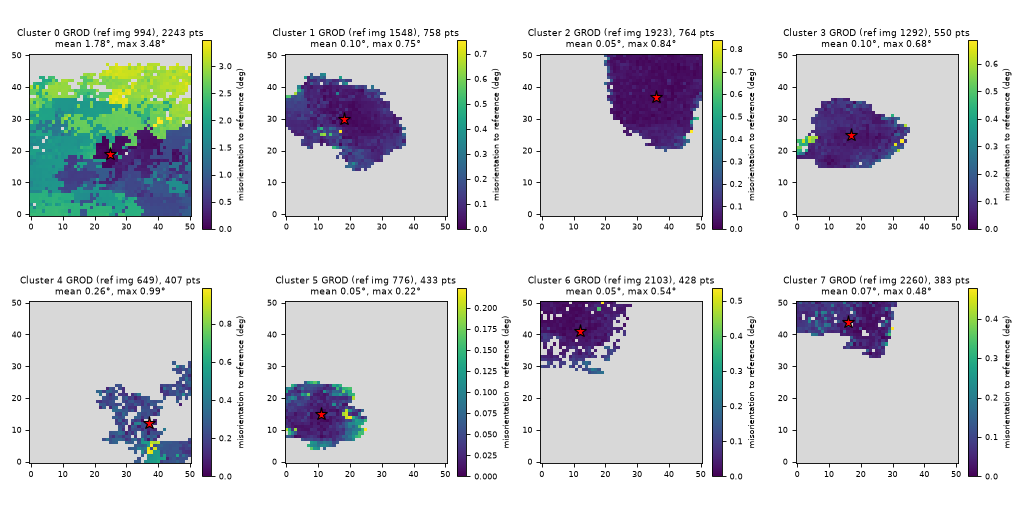

In [14]:
# all clusters (largest first). vmax=None: each panel has its own color scale, vmax=1: common scale
# live=False (default): shown as a PNG image (light for jupyterlab); live=True: interactive plot (zoom, hover values)
fig = OC.plot_clusters_gallery(result, analyzer, min_size=30, max_clusters=8, nb_cols=4, vmax=None, zoom=False, live=False)

In [17]:
# browse clusters one by one: click in the list, then use the up/down arrow keys (or the prev/next buttons)
# property menu: GROD, KAM, Euler angles, strain (sample or crystal frame), lattice parameters, nb of spots, pixel deviation
# each value is read from the .fit file (and grain block) of the matrix of the cluster at each point
# 'crystal axes of cluster ref.': crystal-frame quantities expressed in the same cubic setting for all points
# 'live plot' checkbox: unchecked (default) maps shown as PNG images (fast, light); checked: interactive canvas
# the reference UB matrix of the selected cluster is shown as a copyable list (click in the box, Ctrl+A, Ctrl+C)
OC.visualize_cluster_interactive(result, analyzer, min_size=MIN_CLUSTER_SIZE, zoom=False, properties=True)

ClusterStats(id=2, size=771, pixels=764, ref_img=1923, mean (row, col)=(37.5, 35.8), std_orient=0.09°, max_dev=0.84°)
reference UB matrix: [[0.717568, 0.697548, -0.019077], [-0.44507, 0.479194, 0.755053], [0.535309, -0.532886, 0.653463]]


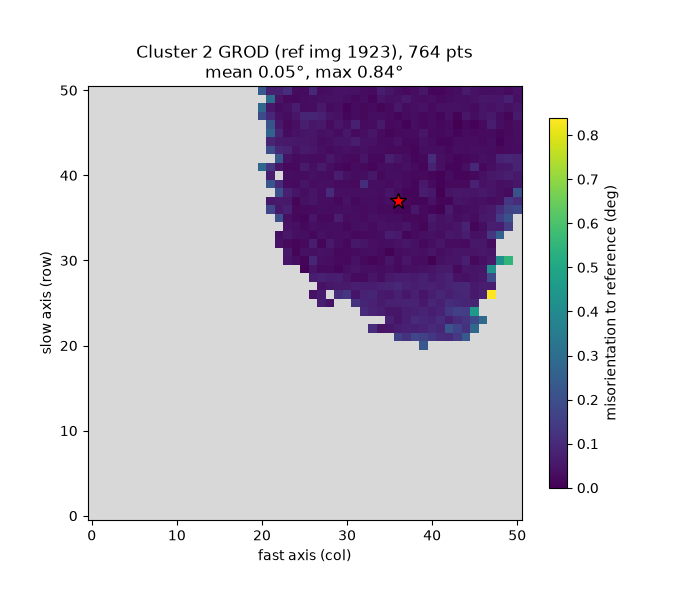

In [18]:
fig, ax = OC.plot_single_cluster(result, analyzer, cluster_id=2, zoom=False)

## properties of a cluster (strain, lattice parameters, Euler angles)

Values are read, for each point, from the `_g#.fit` file (and grain block) of the matrix belonging to the cluster at this point.

Cubic materials: crystal-frame quantities (crystal strain, lattice parameters, Euler angles) are brought to the axes of the cluster reference matrix (`aligned=True`), otherwise they may jump from point to point between equivalent cubic settings:
- crystal-frame strain: recomputed from the sample-frame strain (setting independent) in the axes of the aligned UB
- lattice parameters: written values transformed to the aligned axes (a keeps its fixed value of the deviatoric refinement)
- Euler angles: LaueTools convention (`orientations.calc_Euler_angles`) of the aligned UB

Properties: `OC.PROPERTY_GROUPS`

In [19]:
print(OC.PROPERTY_GROUPS)
fig, ax = OC.plot_cluster_property(result, analyzer, cluster_id=1, prop='ezz_sample', aligned=True,
                                   zoom=False, symmetric=False, percentiles=(2, 98), show_envelope=True)

# values as 2D array (NaN outside the cluster, strain in absolute units)
exz_c0 = OC.cluster_property_map(result, analyzer, cluster_id=0, prop='exz', aligned=True)

{'orientation': ['grod', 'phi', 'theta', 'psi'], 'strain sample frame': ['exx_sample', 'eyy_sample', 'ezz_sample', 'exy_sample', 'exz_sample', 'eyz_sample'], 'strain crystal frame': ['exx', 'eyy', 'ezz', 'exy', 'exz', 'eyz'], 'lattice parameters': ['a', 'b', 'c', 'alpha', 'beta', 'gamma'], 'quality': ['nb_indexed', 'pixdev']}
ClusterStats(id=1, size=784, pixels=758, ref_img=1548, mean (row, col)=(29.5, 18.1), std_orient=0.12°, max_dev=0.94°)


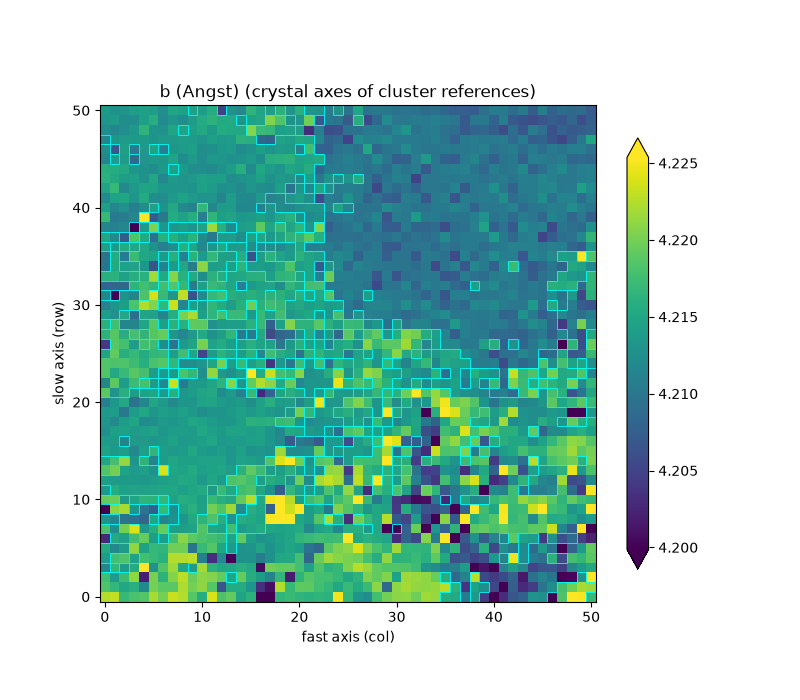

In [20]:
# whole map: property of the primary grain of each point, crystal-frame quantities in the axes of the reference of its cluster
settings = OC.check_crystal_frame_settings(analyzer)
prop = 'b'
bmap = OC.property_map(result, analyzer, prop, aligned=True)
fig, ax = OC.plot_kam(bmap, result, analyzer, cmap='viridis',
                      vmin=np.nanpercentile(bmap, 1), vmax=np.nanpercentile(bmap, 99),
                      title=OC.property_label(prop) + ' (crystal axes of cluster references)')

# KAM and GROD

**Kernel Average Misorientation**: for each map point, mean misorientation between its orientation and those of its neighbours (`connectivity='8'`: 8 first neighbours, or an integer d for all points within distance d). Neighbours with misorientation > `max_angle` (grain boundaries) or belonging to another cluster are ignored. KAM reveals local lattice curvature, i.e. geometrically necessary dislocations.

**GROD** (Grain Reference Orientation Deviation): misorientation of each point to the reference orientation of its cluster, i.e. long-range orientation gradients inside grains.

KAM mean 0.145°, median 0.043°


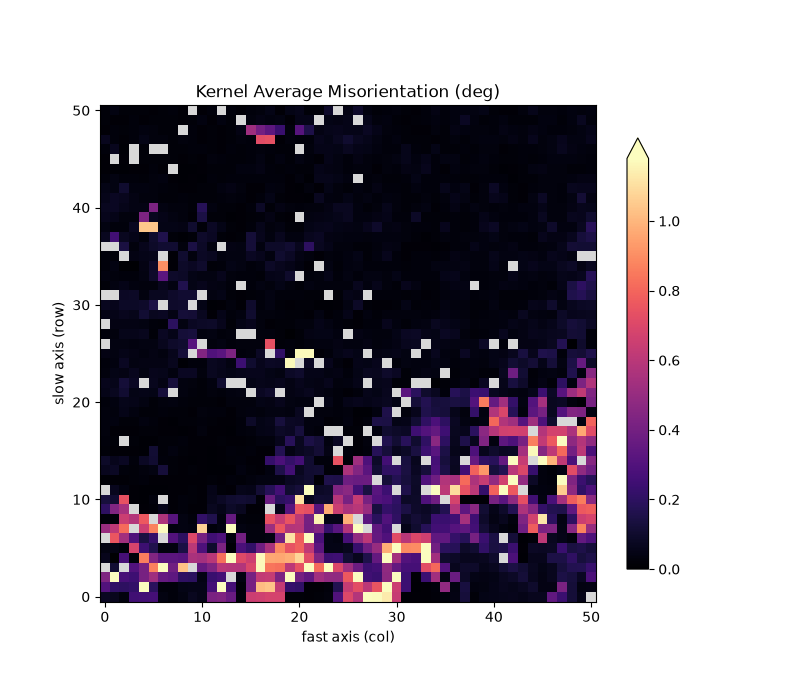

In [21]:
kam = OC.compute_kam(analyzer, result, connectivity='8', max_angle=2.0)
print(f'KAM mean {np.nanmean(kam):.3f}°, median {np.nanmedian(kam):.3f}°')
fig, ax = OC.plot_kam(kam, result, analyzer, vmax=None, show_boundaries=False)

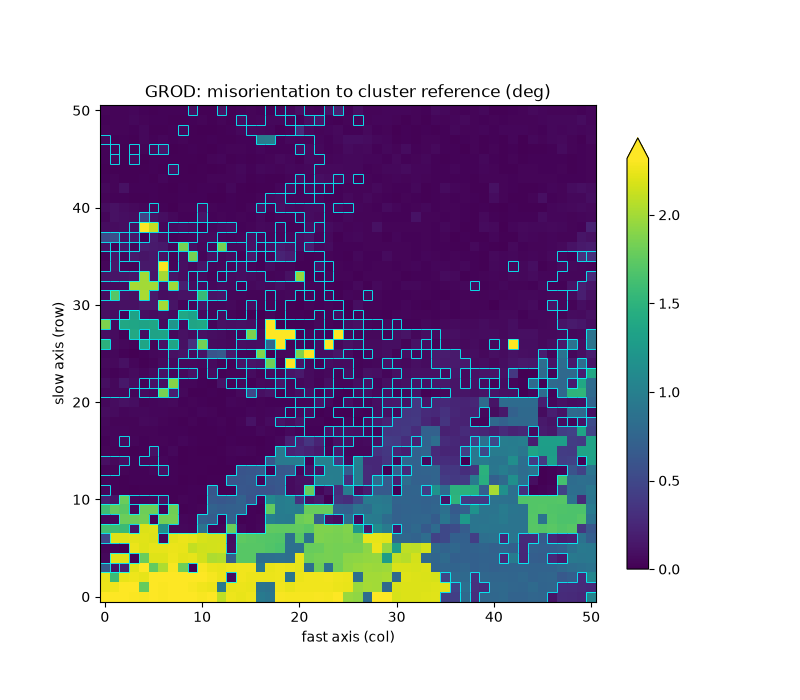

In [22]:
grod = OC.compute_grod_map(result, analyzer)
fig, ax = OC.plot_kam(grod, result, analyzer, cmap='viridis', show_boundaries=True,
                      title='GROD: misorientation to cluster reference (deg)')

## GROD and KAM of a single cluster

Only the orientations of the selected cluster are used, at all its points (also where it is not the primary grain of the point). Red line: envelope of the grain.

GROD reference: `None` = point closest to the cluster barycenter (red star), `'mean'` = mean orientation of the cluster, an image index of the cluster, or any UB matrix.

ClusterStats(id=1, size=784, pixels=758, ref_img=1548, mean (row, col)=(29.5, 18.1), std_orient=0.12°, max_dev=0.94°)
reference UB matrix: [[0.750142, -0.618854, 0.241007], [0.630077, 0.548838, -0.549096], [0.206663, 0.562564, 0.800507]]


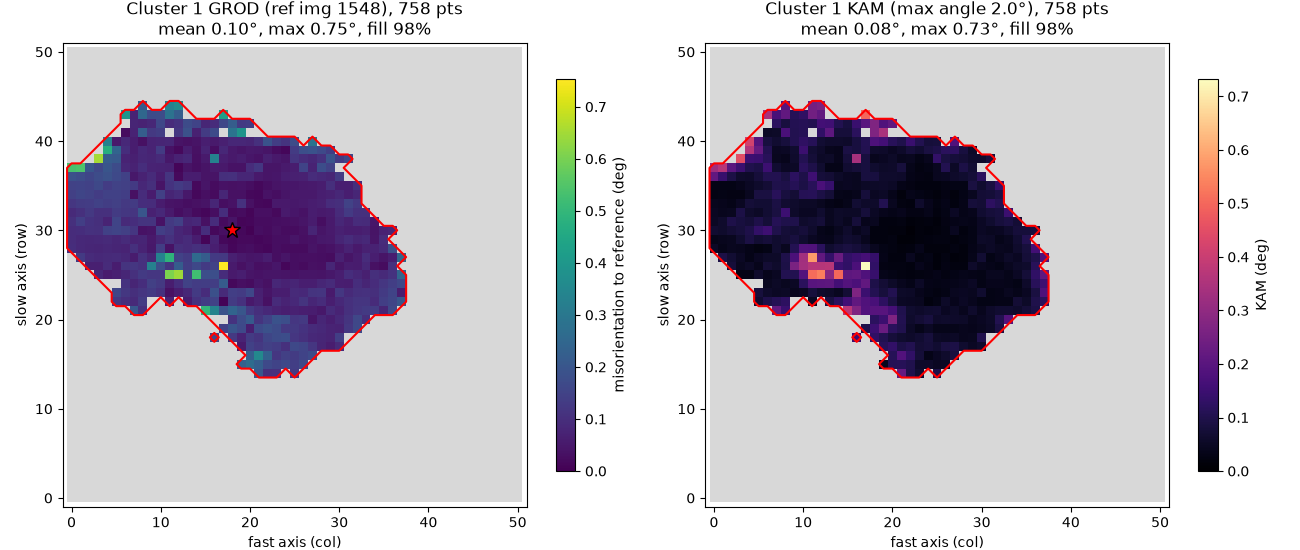

In [23]:
cluster_id = 1
fig = OC.plot_cluster_grod_kam(result, analyzer, cluster_id=cluster_id,
                               reference=None,          # None, 'mean', image index, or UB matrix
                               zoom=False, show_envelope=True,
                               kam_max_angle=2.0, kam_connectivity='8',
                               vmax_grod=None, vmax_kam=None)

# maps as arrays (NaN outside the cluster)
grod_c = OC.compute_grod_map(result, analyzer, cluster_id=cluster_id, reference='mean')
kam_c = OC.compute_kam(analyzer, result, cluster_id=cluster_id)
plt.show()

In [24]:
# browse clusters (click in the list, then up/down arrow keys) and choose the GROD reference
OC.cluster_grod_interactive(result, analyzer, min_size=MIN_CLUSTER_SIZE, zoom=False, show_envelope=True)

# CLUSTER boundaries and envelopes

Even large clusters are sparse (points of other grains in between, several grains per image). The **envelope** of a grain is the region it occupies:

- `method='closing'` (default): morphological closing with a disk of `radius` map steps + hole filling. Bridges gaps up to ~2*radius and follows concave shapes. Envelope pieces with less than 3 points (stray points) are removed
- `method='hull'`: convex hull, i.e. extreme limits of the grain (overestimates concave grains)
- `method='bbox'`: bounding box

`fill` = fraction of the envelope actually occupied by the cluster points.

In [29]:
# main clusters superimposed: envelope outline + light filling + points (slightly shifted per cluster
# so that grains superimposed at the same point remain visible)
fig, ax, envelopes = OC.plot_cluster_envelopes(result, analyzer, min_size=100, max_clusters=10,
                                               method='closing', radius=2.0, show_points=True, fill_alpha=0.15)
for cid, env in envelopes.items():
    rmin, rmax, cmin, cmax = env['bbox']
    print(f"cluster {cid:3d}: {env['nb_points']:4d} pts, envelope area {env['area']:4d}, fill {100 * env['fill_fraction']:3.0f}%, "
          f"rows {rmin}-{rmax}, cols {cmin}-{cmax}, extent {env['extent']:.1f} steps, stray pts {env['nb_outliers']}")

cluster   0: 2243 pts, envelope area 2313, fill  97%, rows 0-47, cols 0-50, extent 67.9 steps, stray pts 0
cluster   1:  758 pts, envelope area  775, fill  98%, rows 14-44, cols 0-37, extent 39.9 steps, stray pts 0
cluster   2:  764 pts, envelope area  772, fill  99%, rows 20-50, cols 20-50, extent 37.6 steps, stray pts 0
cluster   3:  550 pts, envelope area  561, fill  98%, rows 15-36, cols 0-35, extent 36.1 steps, stray pts 0
cluster   4:  407 pts, envelope area  487, fill  84%, rows 0-31, cols 21-50, extent 36.1 steps, stray pts 0
cluster   5:  433 pts, envelope area  440, fill  98%, rows 4-25, cols 0-25, extent 28.2 steps, stray pts 0
cluster   6:  428 pts, envelope area  529, fill  81%, rows 28-50, cols 0-28, extent 33.8 steps, stray pts 0
cluster   7:  383 pts, envelope area  402, fill  95%, rows 33-50, cols 0-31, extent 32.3 steps, stray pts 0
cluster   8:  379 pts, envelope area  386, fill  98%, rows 31-47, cols 25-50, extent 28.0 steps, stray pts 0
cluster   9:  351 pts, envel

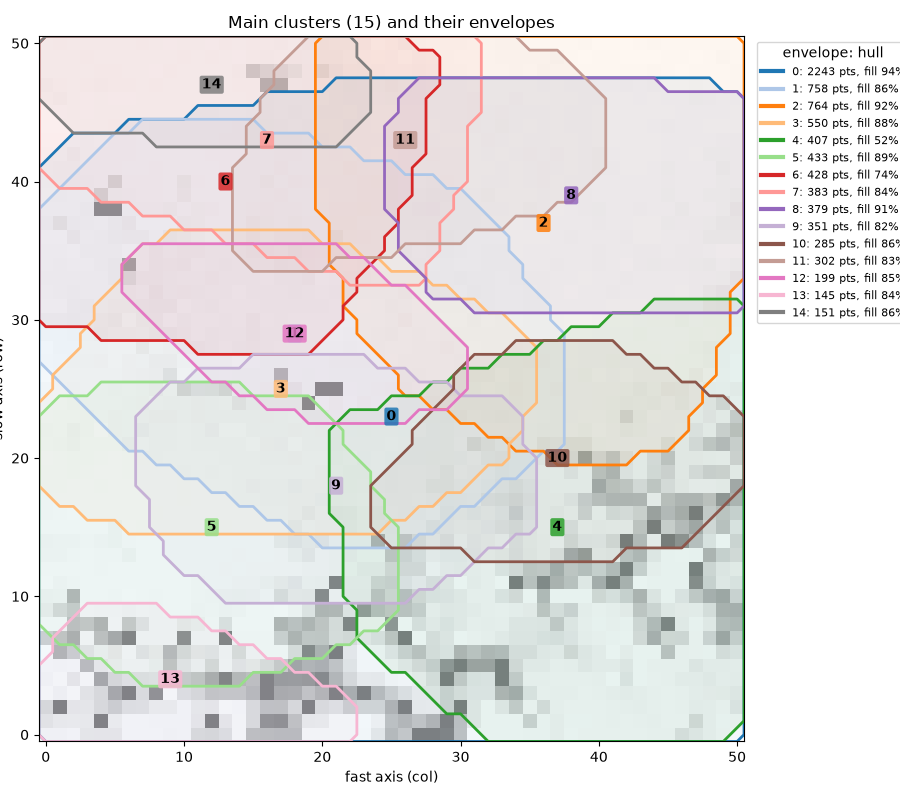

In [28]:
fig.clear('all')
# extreme limits (convex hulls) on top of the KAM map
fig, ax, hulls = OC.plot_cluster_envelopes(result, analyzer, min_size=100, max_clusters=15, method='hull',
                                           show_points=False, fill_alpha=0.05, background=kam)
plt.show()

## misorientation between neighbouring clusters

Pairs of clusters whose envelopes touch (`contact`) or overlap (`overlap`, grains superimposed along the beam or interpenetrating), misorientation between mean orientations and rotation axis (crystal frame of A). For cubic crystals, **Σ3 twins** (60° about <111>, Brandon criterion 8.66°) are identified.

In [30]:
pairs = OC.cluster_pairs_table(result, analyzer, cluster_ids=list(envelopes), envelopes=envelopes,
                               low_angle=5.0, high_angle=15.0)

   A    B misori(deg)       axis (crystal A)         type  dev.Σ3  overlap  contact
   0    4        2.83 [ 0.218  0.932 -0.290]    low-angle   57.67      486        1
   6    9        8.01 [-0.310 -0.412  0.857]       medium   52.79        0        3
   1    9       21.47 [ 0.362 -0.596  0.717]   high-angle   39.59      203       47
   1    6       25.24 [ 0.456 -0.754  0.473]   high-angle   35.93      295       43
   2    8       25.55 [ 0.276 -0.959  0.067]   high-angle   43.84      377        8
   3    7       26.21 [ 0.651 -0.307 -0.694]   high-angle   35.80        9       15
   1    3       26.29 [ 0.681  0.136 -0.719]   high-angle   38.45      446       32
   5    9       28.22 [-0.955 -0.030  0.294]   high-angle   43.16      210       33
   2    3       29.27 [ 0.660  0.168 -0.732]   high-angle   35.74       72       32
   6    7       32.65 [ 0.478  0.867 -0.139]   high-angle   35.82      329       35
   1    4       35.31 [-0.519  0.729  0.447]   high-angle   26.40       75  

## boundary map

Boundaries between neighbouring points whose primary grains belong to different clusters, colored by misorientation class. Where several grains are superimposed, the primary grain (most indexed spots) may switch from point to point, which also produces boundary segments.

In [31]:
fig, ax, bnd = OC.plot_boundary_map(result, analyzer, low_angle=5.0, high_angle=15.0, background='clusters')